In [2]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import networkit as nk
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse import coo_matrix
from collections import Counter

In [3]:
node_df = pd.read_parquet('../03_data/preprocessed_data/nodes_beir_dbpedia.parquet')
wikilinks = pd.read_parquet('../03_data/preprocessed_data/wikilink_edges_beir_dbpedia.parquet')
pagelinks = pd.read_parquet('../03_data/preprocessed_data/pagelink_edges_beir_dbpedia.parquet')

In [5]:
print("Nodes:", len(node_df))
print("Pagelinks:", len(np.ones(len(pagelinks))))
print("Wikilinks:", len(np.ones(len(wikilinks))))

Nodes: 4635920
Pagelinks: 93804726
Wikilinks: 11947165


In [4]:
G_wikilinks = nk.Graph(len(node_df))

G_wikilinks.addEdges(coo_matrix((np.ones(len(wikilinks), dtype=np.int64),
                (
                wikilinks["source"].to_numpy(),
                wikilinks["target"].to_numpy(),
                )))
            )

G_pagelinks = nk.Graph(len(node_df))

G_pagelinks.addEdges(
                coo_matrix((np.ones(len(pagelinks), dtype=np.int64),
                (
                pagelinks["source"].to_numpy(),
                pagelinks["target"].to_numpy(),
                )))
)

In [ ]:
# Check that there are no permutations anymore
wikilinks[(wikilinks["source"]==0)|(wikilinks["target"]==0)]

,source,target
3920965,0,1290550
3993838,0,156540
4717101,0,198523
10336220,0,578804
11014072,0,1434
11478115,0,87705


In [22]:
def calc_node_degrees(G):
    # Degree für alle Knoten berechnen
    degree_sequence = [G.degree(node) for node in range(G.numberOfNodes())]
    degree_count = Counter(degree_sequence)
    lists = sorted(degree_count.items()) # sorted by key, return a list of tuples
    degrees, node_counts = zip(*lists) # unpack a list of pairs into two tuples
    return degree_sequence, degrees, node_counts

In [23]:
degree_sequence, degrees, node_counts = calc_node_degrees(G_wikilinks)
for id, item in enumerate(degree_sequence):
    if item >= 100000:
        print(node_df.iloc[id]["title"], item)

Football player 133430
Association football 101256
United Kingdom 201412
Politician 136101
Taxon 306027
Human 1303091
United States 553011
Film 100548
Species 228297


In [24]:
degree_sequence, degrees, node_counts = calc_node_degrees(G_pagelinks)
for id, item in enumerate(degree_sequence):
    if item >= 100000:
        print(node_df.iloc[id]["title"], item)

England 122733
Association football 116574
Germany 124017
India 115204
United Kingdom 108377
World War II 114660
United States 396061
Canada 123291
France 140063
Animal 184979
Arthropod 130037
Insect 125987


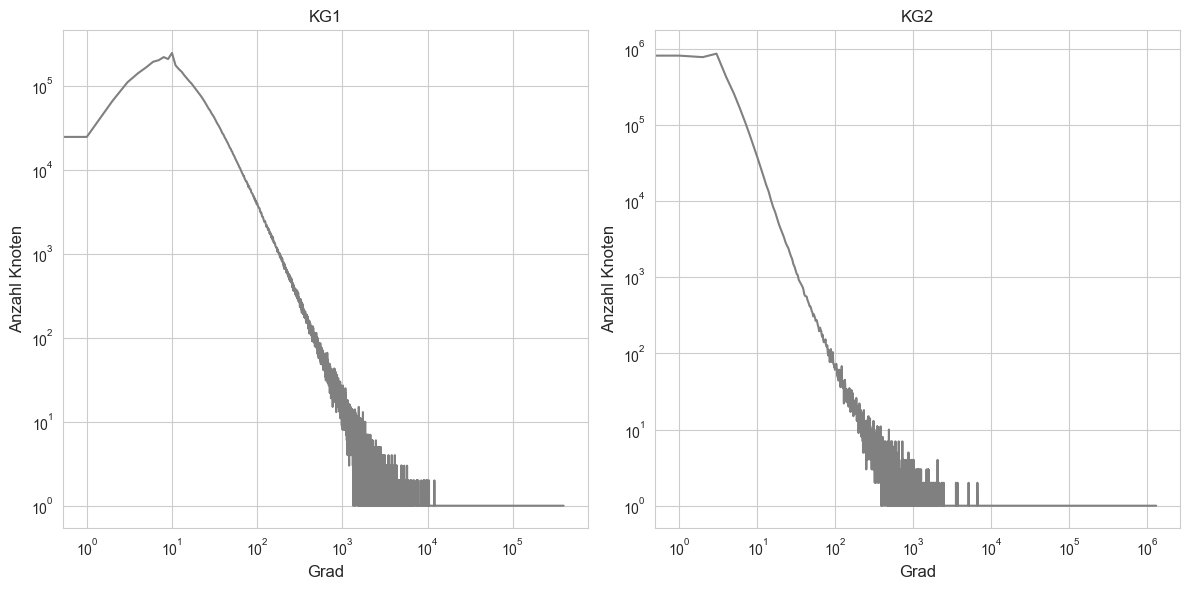

In [25]:
# Abbildung 17
# Calculate degree distribution
import matplotlib.pyplot as plt
import numpy as np

# Daten erstellen
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# Subplots nebeneinander anordnen
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 Zeile, 2 Spalten

# Erste Figur
dd = sorted(nk.centrality.DegreeCentrality(G_pagelinks).run().scores(), reverse=True)
degrees, numberOfNodes = np.unique(dd, return_counts=True)
axes[0].plot(degrees, numberOfNodes, color='grey')
axes[0].set_title('KG1', fontsize=12)
axes[0].set_xscale("log")
axes[0].set_xlabel("Grad", fontsize=12)
axes[0].set_yscale("log")
axes[0].set_ylabel("Anzahl Knoten", fontsize=12)

# Zweite Figur
dd = sorted(nk.centrality.DegreeCentrality(G_wikilinks).run().scores(), reverse=True)
degrees, numberOfNodes = np.unique(dd, return_counts=True)
axes[1].plot(degrees, numberOfNodes, color='grey')
axes[1].set_title('KG2', fontsize=12)
axes[1].set_xscale("log")
axes[1].set_xlabel("Grad", fontsize=12)
axes[1].set_yscale("log")
axes[1].set_ylabel("Anzahl Knoten", fontsize=12)

# Platz optimieren und anzeigen
plt.tight_layout()
plt.savefig('../05_results/Abbildung_17.svg')
plt.show()


In [34]:
print("Abstract:", node_df[node_df["title"]=="Piper PA-46"].text.values[0])
print("Node ID:", node_df[node_df["title"]=="Piper PA-46"].index.values[0])

Abstract: The Piper PA-46 Malibu and Matrix are a family of American light aircraft manufactured by Piper Aircraft of Vero Beach, Florida. The aircraft is powered by a single engine and has the capacity for one pilot and five passengers. Early Malibus were all piston-engined, but a turboprop version, the Malibu Meridian, is also available.The PA-46 is the third single-engined piston aircraft with a pressurized cabin to reach the market, after the Mooney M22 and Cessna P210 Centurion.
Node ID: 279476


In [6]:
def get_labels(G, node_df):
    labels = {}
    for node in G.iterNodes():
        labels[node] = node_df[node_df.index == node].title.values[0]
    return labels

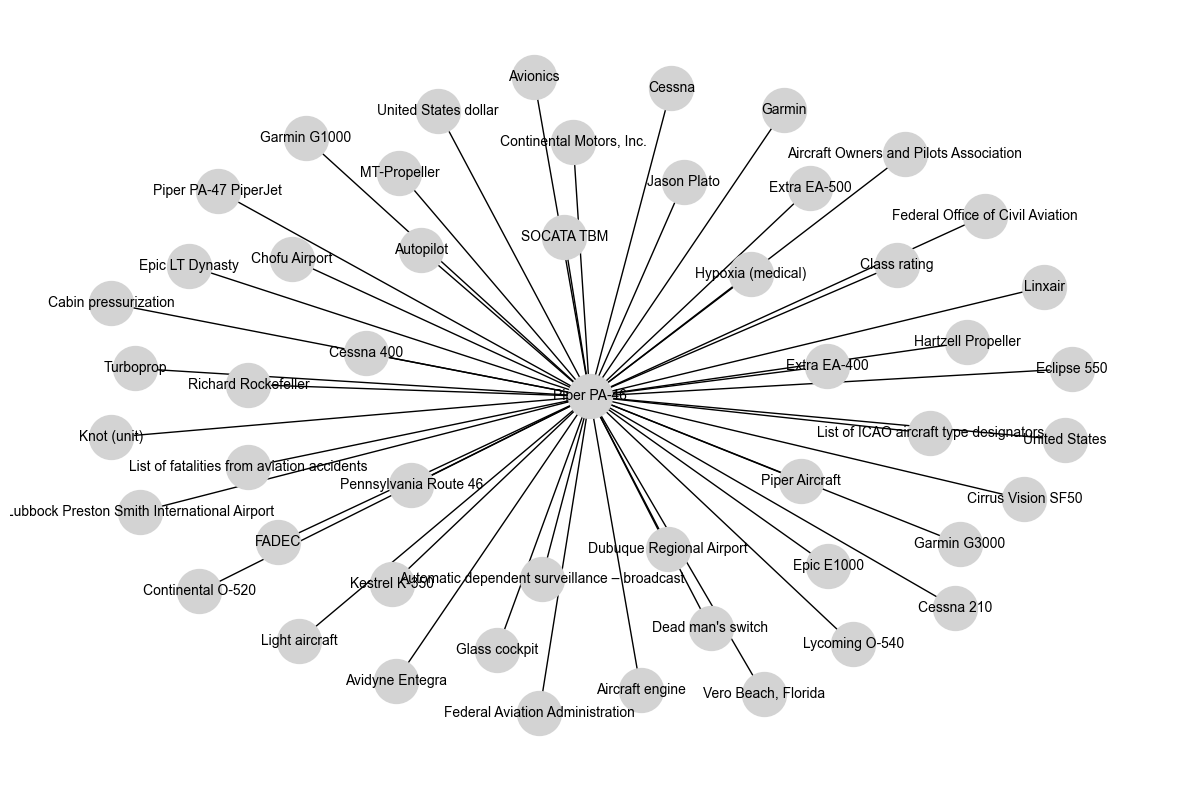

In [35]:
# Abbildung 11
subG = nk.graphtools.subgraphAndNeighborsFromNodes(G_pagelinks, [279476], includeOutNeighbors=True)
nxG = nk.nxadapter.nk2nx(subG)
plt.figure(figsize=(15, 10))
nx.draw_networkx(nxG, pos=nx.spring_layout(nxG), labels = get_labels(subG, node_df), font_size=10, node_size=1000, font_color='black', node_color='lightgrey')	
limits = plt.axis('off')
plt.savefig('../05_results/Abbildung_11.svg')

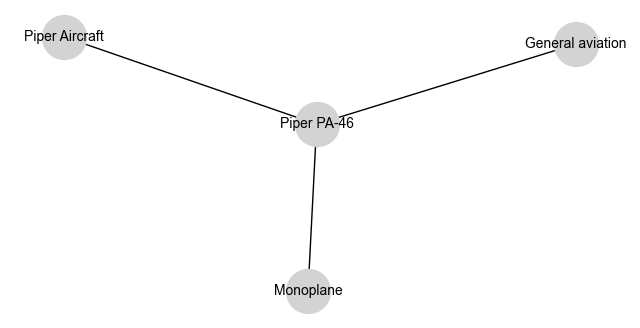

In [7]:
# Abbildung 12
subG = nk.graphtools.subgraphAndNeighborsFromNodes(G_wikilinks, [279476], includeOutNeighbors=True)
nxG = nk.nxadapter.nk2nx(subG)
plt.figure(figsize=(8, 4))
nx.draw_networkx(nxG, pos=nx.spring_layout(nxG), labels = get_labels(subG, node_df), font_size=10, node_size=1000, font_color='black', node_color='lightgrey')	
limits = plt.axis('off')
plt.savefig('../05_results/Abbildung_12.svg')